#### 地表覆盖/土地利用（LCLU）栅格数据分析（昆明）  
LCLU数据来源：https://livingatlas.arcgis.com/landcoverexplorer


In [23]:
import geopandas as gpd
import rasterio as rio
import matplotlib.pyplot as plt



#### 1. 矢量数据准备   
1.1 包含5个行政区；  
1.2 计算面积列；  


In [24]:
path_kunming = 'data/section-6/kunming_districts_utm48.gpkg'
path_kunming_save = 'data/section-6/kunming_5districts_utm48.gpkg'


In [25]:
kunming_gpd = gpd.read_file(path_kunming)
print(kunming_gpd.total_bounds)
kunming_gpd.head(2)
### 筛选主城区
kunming_gpd = kunming_gpd[kunming_gpd['dt_name'].isin(['五华区', '官渡区', '盘龙区', '呈贡区', '西山区'])]
kunming_gpd.head(2)


[ 214587.69295407 2699511.44292862  365546.45119216 2937162.81943723]


,dt_adcode,dt_name,ct_adcode,ct_name,pr_adcode,pr_name,area_km2,geometry
0,530102,五华区,530100,昆明市,530000,云南省,388.457811,"MULTIPOLYGON (((269466.597 2782018.804, 269686..."
1,530103,盘龙区,530100,昆明市,530000,云南省,863.961600,"MULTIPOLYGON (((269635.126 2771844.039, 269631..."


In [26]:
#### 计算面积
kunming_gpd_utm48 = kunming_gpd.to_crs(epsg=32648)
areas = kunming_gpd_utm48.area/1000000


In [27]:
kunming_gpd_utm48['area(km2)'] = areas
kunming_gpd_utm48.head(2)


,dt_adcode,dt_name,ct_adcode,ct_name,pr_adcode,pr_name,area_km2,geometry,area(km2)
0,530102,五华区,530100,昆明市,530000,云南省,388.457811,"MULTIPOLYGON (((269466.597 2782018.804, 269686...",388.681330
1,530103,盘龙区,530100,昆明市,530000,云南省,863.961600,"MULTIPOLYGON (((269635.126 2771844.039, 269631...",864.295297


In [28]:
kunming_gpd_utm48.to_file(path_kunming_save, driver='GPKG')



#### 2. 栅格数据准备

In [29]:
path_lclu_2025 = 'data/section-6/48R_20250101-20251231.tif'
path_lclu_2025_clip = 'data/section-6/48R_20250101-20251231_clip.tif'


In [30]:
lclu_2025_src = rio.open(path_lclu_2025)
lclu_2025_src.meta


{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': 0.0,
 'width': 61044,
 'height': 89013,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 48N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",105],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32648"]]'),
 'transform': Affine(10.0, 0.0, 194780.0,
        0.0, -10.0, 3544360.0)}

In [31]:
lclu_2025_src.read(1).shape


(89013, 61044)

In [32]:
# plt.imshow(lclu_2025_src.read(1), 
#            cmap='tab20', vmin=0, vmax=20)   ## 数据量太大，无法显示


In [33]:
#### 矢量裁剪
from rasterio.mask import mask
# 使用mask函数裁剪栅格
lclu_2025_clip_data, lclu_2025_clip_transform = mask(    
    dataset=lclu_2025_src,
    shapes=list(kunming_gpd_utm48.geometry),  # 几何信息
    crop=True,              # 将栅格裁剪到矢量边界
    all_touched=False,      # 仅裁剪中心点在矢量内的像元
)


In [34]:
lclu_2025_src.close()


In [35]:
lclu_2025_clip_data.shape


(1, 8423, 7026)

In [36]:
# 更新输出文件的元数据（尺寸、坐标系等）
clip_meta = lclu_2025_src.meta.copy()
print(clip_meta)
clip_meta.update({
    "height": lclu_2025_clip_data.shape[1],  # 行数（高度）
    "width": lclu_2025_clip_data.shape[2],   # 列数（宽度）
    "transform": lclu_2025_clip_transform    # 新的地理变换矩阵
    })



{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 0.0, 'width': 61044, 'height': 89013, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 48N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",105],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32648"]]'), 'transform': Affine(10.0, 0.0, 194780.0,
       0.0, -10.0, 3544360.0)}


In [37]:
clip_meta


{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': 0.0,
 'width': 7026,
 'height': 8423,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 48N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",105],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32648"]]'),
 'transform': Affine(10.0, 0.0, 233000.0,
        0.0, -10.0, 2817430.0)}

In [38]:
# 保存裁剪后的栅格
with rio.open(fp = path_lclu_2025_clip, 
            mode = "w", 
            driver = clip_meta['driver'],
            height = clip_meta['height'],
            width = clip_meta['width'],
            count = clip_meta['count'],
            dtype = clip_meta['dtype'],
            crs = clip_meta['crs'],
            transform = lclu_2025_clip_transform) as dst:
    dst.write(lclu_2025_clip_data)


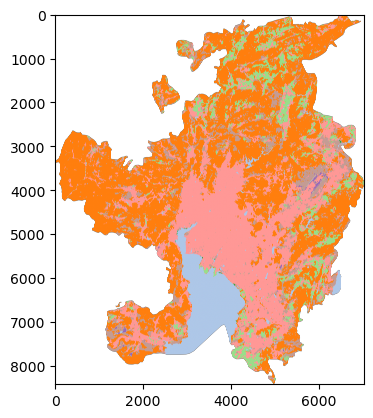

In [56]:
plt.imshow(lclu_2025_clip_data[0], 
                cmap='tab20', vmin=0, vmax=20)
